# Следующий шаг после прогноза: учебная кластеризация финансового датасета

## Что мы делаем в этом ноутбуке

В предыдущем ноутбуке мы решали задачу **прогнозирования**.  
Теперь мы рассмотрим другой важный класс задач искусственного интеллекта — **кластеризацию**.

Кластеризация относится к **обучению без учителя** (*unsupervised learning*).  
Это означает, что модель получает данные **без готовых правильных ответов** и сама пытается найти в них скрытые группы.

## Что такое кластеризация простыми словами

Представьте, что у нас есть много торговых дней, и каждый день описан набором признаков:

- дневная доходность;
- внутридневной диапазон;
- объём торгов;
- краткосрочная волатильность.

Мы не знаем заранее, какие типы дней существуют.  
Но алгоритм может заметить, что некоторые дни похожи друг на друга и образуют устойчивые группы.

Именно эти группы и называются **кластерами**.

## Почему это важно для дипломного проекта

Кластеризация полезна, потому что она помогает:

- находить **скрытую структуру** в данных;
- сегментировать объекты без ручной разметки;
- строить рекомендации;
- искать аномальные или необычные группы;
- подготавливать данные для более сложных AI-систем.

Для диплома это особенно ценно, потому что студент показывает, что умеет:

1. не только загружать и визуализировать данные;
2. не только строить прогноз;
3. но и **искать в данных скрытые типы поведения**.

## Какую задачу мы решаем здесь

Мы будем искать кластеры **торговых дней акций Apple** по нескольким финансовым признакам.

Наша цель:

- подготовить признаки;
- подобрать разумное число кластеров;
- применить алгоритм **KMeans**;
- понять, **какие типы дней** обнаружила модель;
- интерпретировать результат на языке, понятном начинающему разработчику.

## Почему это хороший сюжет для студентов

После этого ноутбука студент сможет использовать идею кластеризации в дипломе, например для:

- сегментации клиентов;
- группировки товаров;
- кластеризации сообщений пользователей;
- группировки изображений по признакам;
- выделения режимов работы оборудования;
- поиска типов финансового поведения.

То есть кластеризация — это не «абстрактная математика», а очень практический AI-инструмент.

## Практическая ячейка 1. Импорт библиотек и загрузка данных

### Назначение ячейки

В этой ячейке мы:

- подключим библиотеки для анализа данных, визуализации и кластеризации;
- загрузим внешний датасет;
- подготовим названия столбцов к удобной работе;
- убедимся, что даты и числовые поля распознаны корректно.

### Краткая теория

Любой AI-проект начинается с данных.  
Если данные загружены некорректно, то дальнейший анализ и обучение модели будут искажены.

Для этого ноутбука нам понадобятся:

- `pandas` — работа с таблицами;
- `matplotlib` — графики;
- `StandardScaler` — стандартизация признаков;
- `KMeans` — алгоритм кластеризации;
- `silhouette_score` — оценка качества разбиения на кластеры;
- `PCA` — уменьшение размерности для визуализации кластеров.

### Как интерпретировать результат

После запуска ячейки проверьте:

- откуда загружены данные;
- сколько строк и столбцов в таблице;
- появились ли удобные названия столбцов: `open`, `high`, `low`, `close`, `volume`, `adjusted`;
- корректно ли распознался столбец `Date`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

dataset_url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"
local_candidates = [
    "finance-charts-apple.csv",
    "./finance-charts-apple.csv",
    "/mnt/data/finance-charts-apple.csv"
]

try:
    raw_df = pd.read_csv(dataset_url)
    data_source = f"Данные загружены из интернета: {dataset_url}"
except Exception:
    loaded = False
    for candidate in local_candidates:
        if Path(candidate).exists():
            raw_df = pd.read_csv(candidate)
            data_source = f"Интернет недоступен, загружена локальная копия: {candidate}"
            loaded = True
            break
    if not loaded:
        raise FileNotFoundError("Не удалось загрузить датасет ни из интернета, ни из локального файла.")

base_df = raw_df.rename(columns={
    "AAPL.Open": "open",
    "AAPL.High": "high",
    "AAPL.Low": "low",
    "AAPL.Close": "close",
    "AAPL.Volume": "volume",
    "AAPL.Adjusted": "adjusted"
}).copy()

base_df["Date"] = pd.to_datetime(base_df["Date"])
base_df = base_df.sort_values("Date").reset_index(drop=True)

print(data_source)
print(f"Размер таблицы: {base_df.shape[0]} строк, {base_df.shape[1]} столбцов")
print("\nТипы данных:")
print(base_df.dtypes)

display(base_df.head())

Данные загружены из интернета: https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv
Размер таблицы: 506 строк, 11 столбцов

Типы данных:
Date         datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
volume                int64
adjusted            float64
dn                  float64
mavg                float64
up                  float64
direction            object
dtype: object


,Date,open,high,low,close,volume,adjusted,dn,mavg,up,direction
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,106.741052,117.927667,129.114281,Increasing
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,107.842423,118.940333,130.038244,Increasing
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,108.894245,119.889167,130.884089,Decreasing
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,109.785449,120.763500,131.741551,Increasing
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,110.372516,121.720167,133.067817,Increasing


## Практическая ячейка 2. Первичный обзор финансового ряда

### Назначение ячейки

Сейчас мы посмотрим на базовую форму данных:

- выведем основные статистики;
- посмотрим на изменение скорректированной цены `adjusted` во времени;
- ещё раз свяжем таблицу с реальной бизнес-задачей.

### Краткая теория

Перед обучением модели полезно понять:

- какие диапазоны значений у признаков;
- есть ли общий тренд;
- нет ли пропусков и странных значений;
- как выглядит объект исследования визуально.

В финансовом анализе столбец `adjusted` часто удобнее обычной цены закрытия, потому что он корректируется с учётом корпоративных событий и обычно лучше подходит для временного анализа.

### Как интерпретировать результат

После выполнения ячейки посмотрите:

- как меняется `adjusted` по датам;
- какие средние и максимальные значения у цены и объёма;
- похож ли ряд на реалистичный финансовый временной ряд.

,open,high,low,close,adjusted,volume
count,506.000,506.000,506.000,506.000,506.000,5.060000e+02
mean,112.935,113.919,111.942,112.958,110.459,4.317842e+07
std,11.287,11.252,11.264,11.245,10.538,1.985253e+07
min,90.000,91.670,89.470,90.340,89.008,1.147590e+07
25%,105.482,106.350,104.658,105.672,103.485,2.974240e+07
50%,112.890,114.145,111.800,113.025,110.821,3.747460e+07
75%,122.267,123.497,121.600,122.180,119.255,5.076395e+07
max,135.670,136.270,134.840,135.510,135.510,1.622063e+08


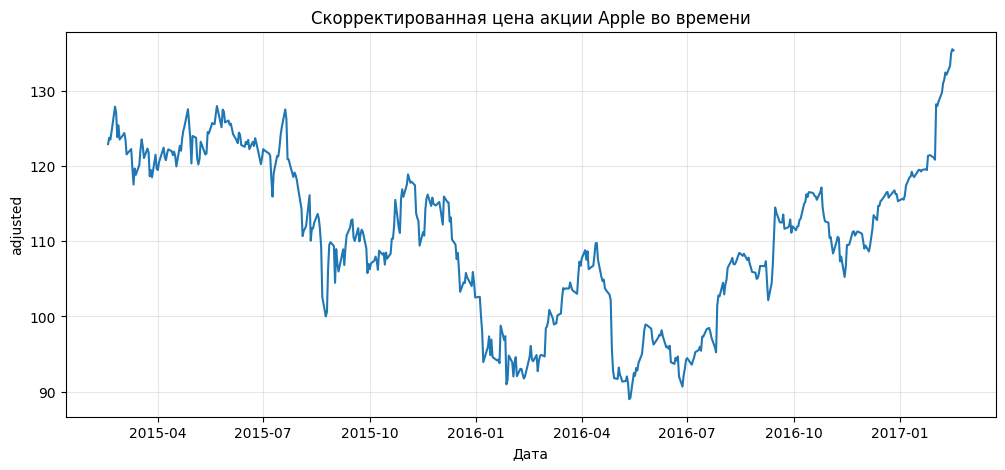

In [ ]:
display(base_df[["open", "high", "low", "close", "adjusted", "volume"]].describe().round(3))

plt.figure(figsize=(12, 5))
plt.plot(base_df["Date"], base_df["adjusted"])
plt.title("Скорректированная цена акции Apple во времени")
plt.xlabel("Дата")
plt.ylabel("adjusted")
plt.grid(alpha=0.3)
plt.show()

## Практическая ячейка 3. Создание признаков для кластеризации

### Назначение ячейки

В этой ячейке мы создадим признаки, по которым алгоритм будет искать группы похожих дней.

Мы подготовим:

- `daily_return_pct` — дневная доходность в процентах;
- `intraday_range_pct` — внутридневной диапазон в процентах;
- `open_close_diff_pct` — изменение от открытия до закрытия;
- `volume_mln` — объём торгов в миллионах;
- `volatility_5` — краткосрочная волатильность за 5 дней.

### Краткая теория

Кластеризация работает не на «сыром ощущении», а на **признаках**.

Хороший признак — это числовая характеристика, которая помогает различать объекты.  
В нашем случае объект — это **один торговый день**.

Почему именно такие признаки полезны:

- доходность показывает направление движения;
- диапазон показывает, насколько день был «нервным»;
- изменение от открытия к закрытию показывает внутридневной итог;
- объём отражает активность рынка;
- волатильность помогает увидеть, насколько неспокойным был недавний период.

### Как интерпретировать результат

После запуска ячейки убедитесь, что в таблице появились новые столбцы.  
Именно они станут входом для алгоритма KMeans.

In [ ]:
feature_df = base_df.copy()

feature_df["daily_return_pct"] = feature_df["adjusted"].pct_change() * 100
feature_df["intraday_range_pct"] = (feature_df["high"] - feature_df["low"]) / feature_df["open"] * 100
feature_df["open_close_diff_pct"] = (feature_df["close"] - feature_df["open"]) / feature_df["open"] * 100
feature_df["volume_mln"] = feature_df["volume"] / 1_000_000
feature_df["volatility_5"] = feature_df["daily_return_pct"].rolling(window=5).std()

display(
    feature_df[
        ["Date", "adjusted", "daily_return_pct", "intraday_range_pct",
         "open_close_diff_pct", "volume_mln", "volatility_5"]
    ].head(10).round(3)
)

,Date,adjusted,daily_return_pct,intraday_range_pct,open_close_diff_pct,volume_mln,volatility_5
0,2015-02-17,122.905,NaN,1.537,0.267,63.152,NaN
1,2015-02-18,123.761,0.696,1.042,0.854,44.892,NaN
2,2015-02-19,123.501,-0.210,0.545,-0.023,37.362,NaN
3,2015-02-20,124.511,0.817,1.127,0.684,48.948,NaN
4,2015-02-23,127.876,2.703,2.569,2.292,70.974,NaN
5,2015-02-24,127.078,-0.624,1.828,-0.579,69.228,1.285
6,2015-02-25,123.828,-2.557,2.622,-2.106,74.712,1.933
7,2015-02-26,125.395,1.266,3.308,1.266,91.288,1.999
8,2015-02-27,123.511,-1.503,1.792,-1.185,62.015,2.121
9,2015-03-02,124.117,0.490,1.532,-0.124,48.097,1.526


## Практическая ячейка 4. Визуальный анализ созданных признаков

### Назначение ячейки

Теперь мы визуально посмотрим на признаки, которые будут участвовать в кластеризации.

Мы построим:

- график дневной доходности;
- график объёма торгов;
- график краткосрочной волатильности.

### Краткая теория

Перед кластеризацией полезно увидеть, как ведут себя признаки:

- есть ли резкие всплески;
- часто ли встречаются большие изменения;
- бывают ли периоды спокойствия и периоды напряжения.

Если признаки действительно различаются по поведению, кластеризация обычно работает осмысленнее.

### Как интерпретировать результат

На графиках обратите внимание:

- когда доходность резко уходит вверх или вниз;
- в какие дни объём особенно высокий;
- как меняется волатильность во времени.

Это уже подсказывает, что в данных могут существовать разные типы торговых дней.

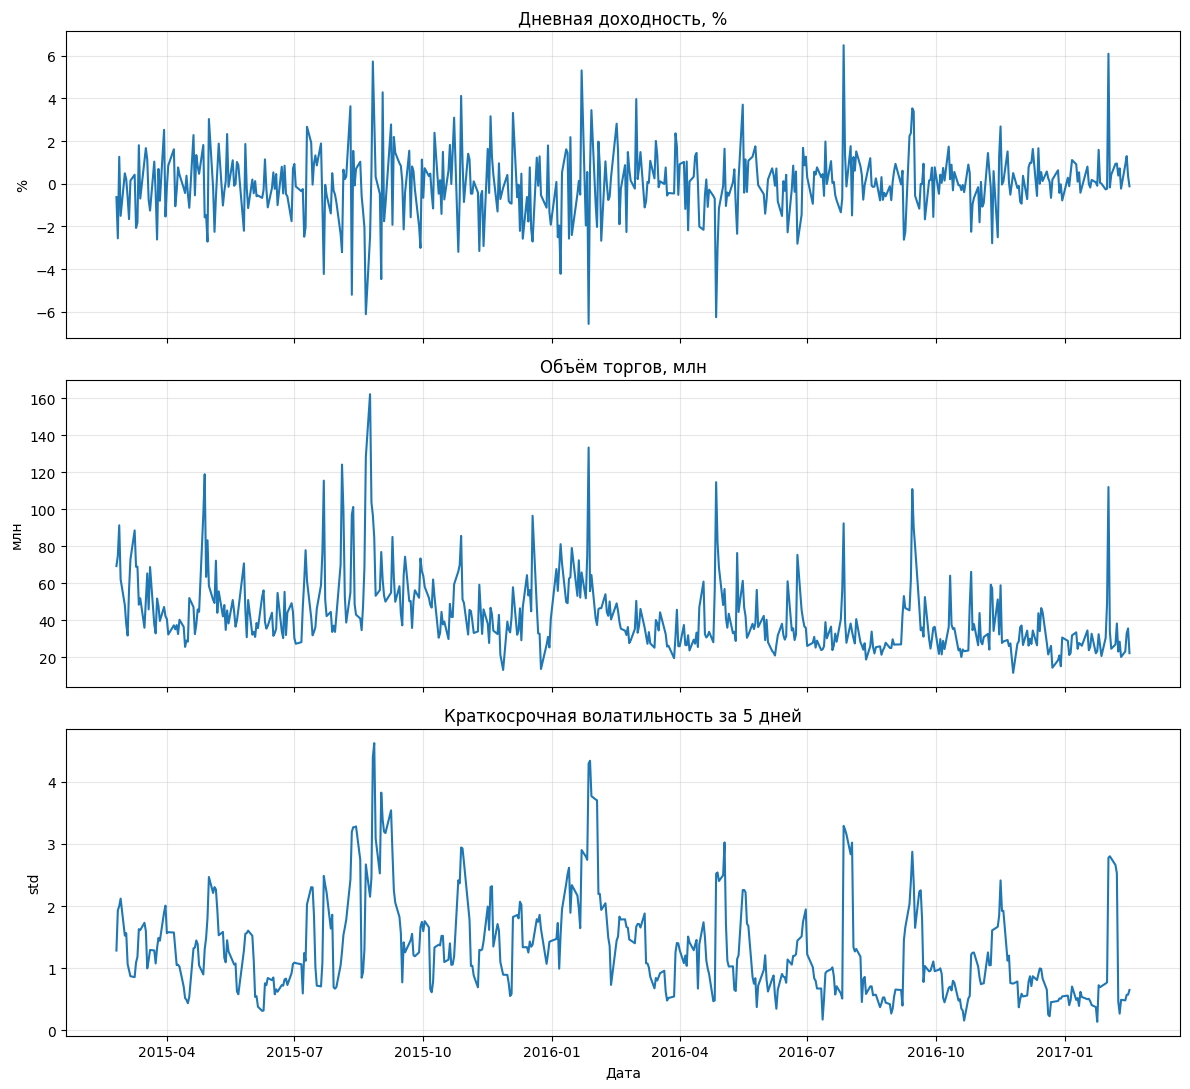

In [ ]:
plot_df = feature_df.dropna(subset=["daily_return_pct", "volume_mln", "volatility_5"]).copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

axes[0].plot(plot_df["Date"], plot_df["daily_return_pct"])
axes[0].set_title("Дневная доходность, %")
axes[0].set_ylabel("%")
axes[0].grid(alpha=0.3)

axes[1].plot(plot_df["Date"], plot_df["volume_mln"])
axes[1].set_title("Объём торгов, млн")
axes[1].set_ylabel("млн")
axes[1].grid(alpha=0.3)

axes[2].plot(plot_df["Date"], plot_df["volatility_5"])
axes[2].set_title("Краткосрочная волатильность за 5 дней")
axes[2].set_xlabel("Дата")
axes[2].set_ylabel("std")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Практическая ячейка 5. Подготовка матрицы признаков и стандартизация

### Назначение ячейки

Сейчас мы:

- выберем признаки для кластеризации;
- удалим строки с пропусками;
- подготовим матрицу `X`;
- стандартизируем данные.

### Краткая теория

Алгоритм KMeans чувствителен к масштабу признаков.

Например:

- объём торгов может измеряться десятками миллионов;
- доходность — единицами процентов;
- волатильность — ещё в другом диапазоне.

Если не привести признаки к сопоставимому масштабу, один крупный по числам признак будет доминировать над остальными.

Для этого применяется **стандартизация**:

- среднее значение становится близким к 0;
- стандартное отклонение становится близким к 1.

### Как интерпретировать результат

После выполнения ячейки проверьте:

- сколько строк осталось после удаления пропусков;
- какие признаки вошли в модель;
- что стандартизированная матрица готова к кластеризации.

In [ ]:
cluster_features = [
    "daily_return_pct",
    "intraday_range_pct",
    "open_close_diff_pct",
    "volume_mln",
    "volatility_5"
]

cluster_df = feature_df[["Date"] + cluster_features].dropna().reset_index(drop=True).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_features])

print(f"Строк для кластеризации: {cluster_df.shape[0]}")
print("Используемые признаки:", cluster_features)
print("Размер матрицы X_scaled:", X_scaled.shape)

scaled_preview = pd.DataFrame(X_scaled, columns=cluster_features).head().round(3)
display(scaled_preview)

Строк для кластеризации: 501
Используемые признаки: ['daily_return_pct', 'intraday_range_pct', 'open_close_diff_pct', 'volume_mln', 'volatility_5']
Размер матрицы X_scaled: (501, 5)


,daily_return_pct,intraday_range_pct,open_close_diff_pct,volume_mln,volatility_5
0,-0.424,0.047,-0.475,1.316,-0.062
1,-1.689,0.738,-1.677,1.592,0.768
2,0.813,1.334,0.977,2.426,0.853
3,-0.999,0.016,-0.952,0.953,1.009
4,0.306,-0.211,-0.117,0.253,0.247


## Практическая ячейка 6. Выбор числа кластеров: метод локтя и silhouette score

### Назначение ячейки

В этой ячейке мы подберём разумное количество кластеров.

Для этого используем два подхода:

- **метод локтя** — смотрим, как уменьшается внутрикластерная ошибка;
- **silhouette score** — оцениваем, насколько хорошо объекты отделены от соседних кластеров.

### Краткая теория

KMeans требует заранее указать число кластеров `k`.  
Но это число не всегда известно заранее.

#### Метод локтя
Для каждого `k` считается **inertia** — сумма расстояний от объектов до центров своих кластеров.  
Чем меньше значение, тем лучше подгонка.  
Но слишком большое `k` приводит к переусложнению.

Мы ищем точку, где улучшение начинает замедляться — это и есть «локоть».

#### Silhouette score
Эта метрика показывает, насколько объект похож на свой кластер и не похож на соседние.

- ближе к `1` — хорошее разделение;
- около `0` — кластеры пересекаются;
- меньше `0` — объект, вероятно, попал не туда.

### Как интерпретировать результат

Смотрите сразу на два графика и таблицу:

- inertia должна заметно падать, а затем замедляться;
- silhouette score желательно выбирать побольше;
- итоговый `k` должен быть не только математически удобным, но и **понятным по смыслу**.

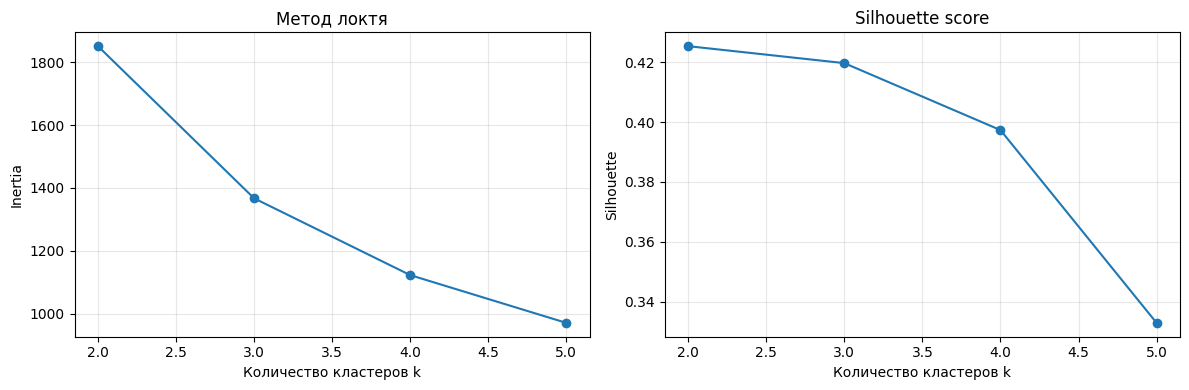

,k,inertia,silhouette_score
0,2,1850.5065,0.4254
1,3,1367.1874,0.4197
2,4,1123.1485,0.3973
3,5,971.3382,0.3329


Лучшее k по silhouette score: 2
Для учебной интерпретации выбираем k = 3, потому что это хороший баланс между качеством и понятностью.


In [ ]:
k_values = list(range(2, 6))
inertia_values = []
silhouette_values = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia_values.append(model.inertia_)
    silhouette_values.append(
        silhouette_score(X_scaled, labels, sample_size=min(300, len(X_scaled)), random_state=42)
    )

comparison_df = pd.DataFrame({
    "k": k_values,
    "inertia": inertia_values,
    "silhouette_score": silhouette_values
}).round(4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, inertia_values, marker="o")
axes[0].set_title("Метод локтя")
axes[0].set_xlabel("Количество кластеров k")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(k_values, silhouette_values, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Количество кластеров k")
axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(comparison_df)

best_k = comparison_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
best_k = int(best_k)
chosen_k = 3

print(f"Лучшее k по silhouette score: {best_k}")
print(f"Для учебной интерпретации выбираем k = {chosen_k}, потому что это хороший баланс между качеством и понятностью.")

## Практическая ячейка 7. Обучение модели KMeans и получение кластеров

### Назначение ячейки

Теперь мы:

- обучим модель KMeans;
- присвоим каждому торговому дню номер кластера;
- построим таблицу средних значений по кластерам;
- дадим кластерам понятные названия.

### Краткая теория

Алгоритм **KMeans** работает так:

1. выбирает `k` центров;
2. относит каждый объект к ближайшему центру;
3. пересчитывает центры;
4. повторяет процесс до стабилизации.

Результат — группы объектов, похожих по своим признакам.

Важно помнить:  
номера кластеров `0`, `1`, `2` **не имеют собственного смысла**.  
Смысл появляется только после интерпретации средних значений признаков внутри каждого кластера.

### Как интерпретировать результат

В таблице посмотрите:

- в каком кластере доходность положительная или отрицательная;
- где выше объём;
- где выше волатильность;
- сколько дней попало в каждый кластер.

На основе этого мы сможем назвать кластеры человеческим языком.

In [ ]:
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=20)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    cluster_df
    .groupby("cluster")
    .agg(
        count=("cluster", "size"),
        daily_return_pct_mean=("daily_return_pct", "mean"),
        intraday_range_pct_mean=("intraday_range_pct", "mean"),
        open_close_diff_pct_mean=("open_close_diff_pct", "mean"),
        volume_mln_mean=("volume_mln", "mean"),
        volatility_5_mean=("volatility_5", "mean")
    )
    .round(3)
    .sort_values("daily_return_pct_mean", ascending=False)
)

cluster_order = cluster_summary.index.tolist()
name_map = {
    cluster_order[0]: "Рост и активность",
    cluster_order[1]: "Спокойный рынок",
    cluster_order[2]: "Падение и напряжение"
}

cluster_df["cluster_name"] = cluster_df["cluster"].map(name_map)
cluster_summary["cluster_name"] = cluster_summary.index.map(name_map)

display(cluster_summary)

print("\nКоличество дней в каждом кластере:")
display(cluster_df["cluster_name"].value_counts().rename_axis("cluster_name").to_frame("count"))

,count,daily_return_pct_mean,intraday_range_pct_mean,open_close_diff_pct_mean,volume_mln_mean,volatility_5_mean,cluster_name
cluster,,,,,,,
0,71,2.025,2.850,1.615,60.772,2.261,Рост и активность
1,336,0.143,1.304,0.120,33.597,0.993,Спокойный рынок
2,94,-1.918,2.642,-1.518,63.613,1.851,Падение и напряжение



Количество дней в каждом кластере:


,count
cluster_name,
Спокойный рынок,336
Падение и напряжение,94
Рост и активность,71


## Практическая ячейка 8. Визуализация кластеров на плоскости PCA

### Назначение ячейки

Сейчас мы попробуем «увидеть» найденные кластеры на графике.

Для этого применим:

- **PCA** для сжатия 5 признаков в 2 координаты;
- цветовую раскраску по кластерам.

### Краткая теория

У нас 5 признаков, поэтому напрямую нарисовать пространство модели трудно.  
Метод **PCA** уменьшает размерность и помогает показать данные на двумерном графике.

Важно понимать:  
PCA не заменяет кластеризацию.  
Он просто помогает визуально представить многомерные данные.

### Как интерпретировать результат

На графике каждый кружок — это один торговый день.

Если кластеры действительно различаются, то:

- точки одного цвета будут группироваться вместе;
- между цветами появится некоторое разделение;
- можно будет визуально увидеть разные режимы поведения рынка.

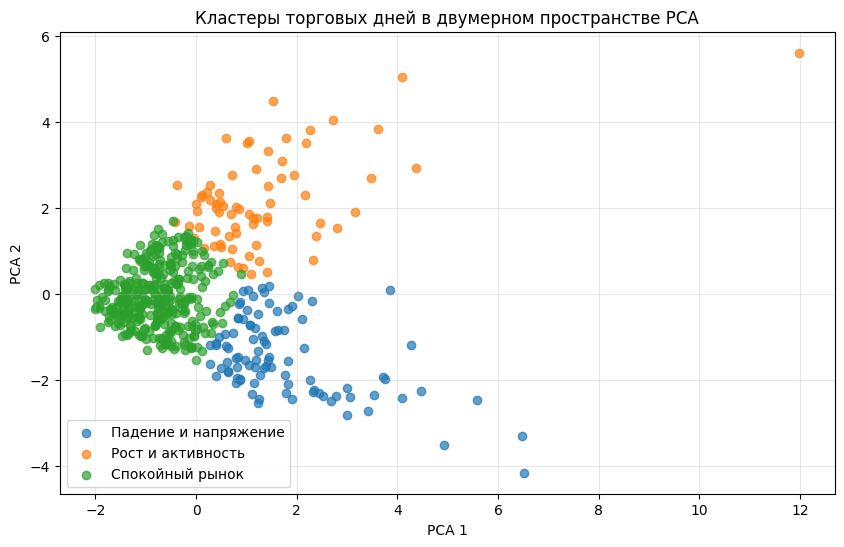

Суммарно две PCA-компоненты объясняют примерно 76.16% вариации признаков.


In [ ]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

cluster_df["pca_1"] = pca_components[:, 0]
cluster_df["pca_2"] = pca_components[:, 1]

plt.figure(figsize=(10, 6))
for name in cluster_df["cluster_name"].unique():
    subset = cluster_df[cluster_df["cluster_name"] == name]
    plt.scatter(subset["pca_1"], subset["pca_2"], label=name, alpha=0.7)

plt.title("Кластеры торговых дней в двумерном пространстве PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

explained = pca.explained_variance_ratio_.sum()
print(f"Суммарно две PCA-компоненты объясняют примерно {explained:.2%} вариации признаков.")

## Практическая ячейка 9. Кластеры на временной шкале и реальные примеры дней

### Назначение ячейки

Теперь посмотрим на кластеры не в абстрактном пространстве признаков, а на реальной временной оси.

Мы:

- нанесём найденные кластеры на график цены;
- выведем примеры нескольких дней из каждого кластера.

### Краткая теория

Очень важно связывать результат AI-модели с исходной предметной областью.  
В нашем случае это значит:  
нужно увидеть, **в какие периоды** встречались те или иные типы торговых дней.

Такой шаг особенно ценен в дипломе, потому что он показывает не просто запуск алгоритма, а **осмысленную интерпретацию результата**.

### Как интерпретировать результат

Смотрите на два типа вывода:

1. **График цены с цветными точками**  
   Он показывает, в каких местах временного ряда возникали разные режимы рынка.

2. **Таблица примеров дней**  
   Она позволяет увидеть реальные значения признаков для каждого типа кластера.

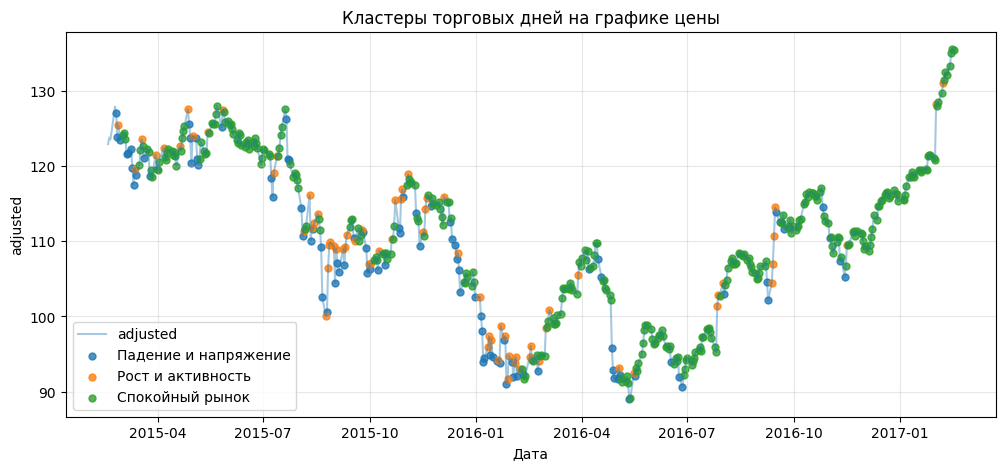

,Date,cluster_name,daily_return_pct,intraday_range_pct,open_close_diff_pct,volume_mln,volatility_5
0,2015-02-24,Падение и напряжение,-0.624,1.828,-0.579,69.228,1.285
1,2015-02-25,Падение и напряжение,-2.557,2.622,-2.106,74.712,1.933
2,2015-02-27,Падение и напряжение,-1.503,1.792,-1.185,62.015,2.121
3,2015-03-05,Падение и напряжение,-1.657,2.325,-1.688,56.517,0.972
4,2015-03-06,Падение и напряжение,0.150,2.422,-1.402,72.842,0.872
5,2015-02-26,Рост и активность,1.266,3.308,1.266,91.288,1.999
6,2015-03-12,Рост и активность,1.808,2.674,1.750,48.363,1.630
7,2015-03-18,Рост и активность,1.126,2.197,1.157,65.271,0.999
8,2015-03-30,Рост и активность,2.531,1.935,1.870,47.100,1.901
9,2015-04-06,Рост и активность,1.620,2.555,2.314,37.194,1.576


In [ ]:
price_view_df = cluster_df.merge(base_df[["Date", "adjusted"]], on="Date", how="left")

plt.figure(figsize=(12, 5))
plt.plot(base_df["Date"], base_df["adjusted"], alpha=0.4, label="adjusted")

for name in price_view_df["cluster_name"].unique():
    subset = price_view_df[price_view_df["cluster_name"] == name]
    plt.scatter(subset["Date"], subset["adjusted"], label=name, s=25, alpha=0.8)

plt.title("Кластеры торговых дней на графике цены")
plt.xlabel("Дата")
plt.ylabel("adjusted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

examples_df = (
    cluster_df[
        ["Date", "cluster_name", "daily_return_pct", "intraday_range_pct",
         "open_close_diff_pct", "volume_mln", "volatility_5"]
    ]
    .groupby("cluster_name", group_keys=False)
    .head(5)
    .sort_values(["cluster_name", "Date"])
    .reset_index(drop=True)
)

display(examples_df.round(3))

## Практическая ячейка 10. Итоговая интерпретация и проверка результата

### Назначение ячейки

В финальной ячейке мы:

- сформулируем вывод по найденным кластерам;
- объясним, почему это уже полноценный AI-компонент диплома;
- выполним простые проверки через `assert`.

### Краткая теория

В хорошем учебном ноутбуке важно не только получить результат, но и ответить на вопросы:

- что именно нашла модель;
- зачем это нужно бизнесу;
- как это можно использовать в приложении;
- почему это считается задачей ИИ.

Кластеризация — это задача ИИ, потому что алгоритм без готовой разметки самостоятельно находит структуру в данных.

### Как интерпретировать результат

После выполнения ячейки вы увидите:

- текстовое резюме;
- несколько технических проверок;
- готовую идею, как перенести этот подход в дипломный проект.

In [ ]:
cluster_counts = cluster_df["cluster_name"].value_counts()

assert cluster_df.shape[0] > 100, "Для кластеризации должно быть достаточно наблюдений."
assert cluster_df["cluster"].nunique() == chosen_k, "Число найденных кластеров не совпадает с выбранным k."
assert cluster_counts.min() > 20, "Один из кластеров получился слишком маленьким для учебной интерпретации."
assert cluster_summary["daily_return_pct_mean"].max() > 0, "Должен существовать хотя бы один кластер с положительной средней доходностью."
assert cluster_summary["daily_return_pct_mean"].min() < 0, "Должен существовать хотя бы один кластер с отрицательной средней доходностью."

print("Проверки пройдены успешно. Кластеры найдены корректно.")

print("\nИтоговая интерпретация:")
print("1. Модель KMeans нашла несколько устойчивых типов торговых дней без готовой разметки.")
print("2. Мы увидели, что дни можно разделить на спокойные, растущие и напряжённые/падающие.")
print("3. Это и есть пример обучения без учителя — важного направления искусственного интеллекта.")
print("4. Такой подход легко переносится в диплом: можно кластеризовать клиентов, товары, изображения, тексты, заявки или производственные режимы.")

print("\nПочему это мотивирует для диплома:")
print("- прогноз отвечает на вопрос 'что будет дальше?';")
print("- кластеризация отвечает на вопрос 'какие скрытые типы объектов уже есть в данных?';")
print("- если студент включает оба подхода, диплом выглядит сильнее и более профессионально.")

Проверки пройдены успешно. Кластеры найдены корректно.

Итоговая интерпретация:
1. Модель KMeans нашла несколько устойчивых типов торговых дней без готовой разметки.
2. Мы увидели, что дни можно разделить на спокойные, растущие и напряжённые/падающие.
3. Это и есть пример обучения без учителя — важного направления искусственного интеллекта.
4. Такой подход легко переносится в диплом: можно кластеризовать клиентов, товары, изображения, тексты, заявки или производственные режимы.

Почему это мотивирует для диплома:
- прогноз отвечает на вопрос 'что будет дальше?';
- кластеризация отвечает на вопрос 'какие скрытые типы объектов уже есть в данных?';
- если студент включает оба подхода, диплом выглядит сильнее и более профессионально.
